### Architecture 
here the FiLM applied to mid stage with the frozen backbone ?

<br>
<br>

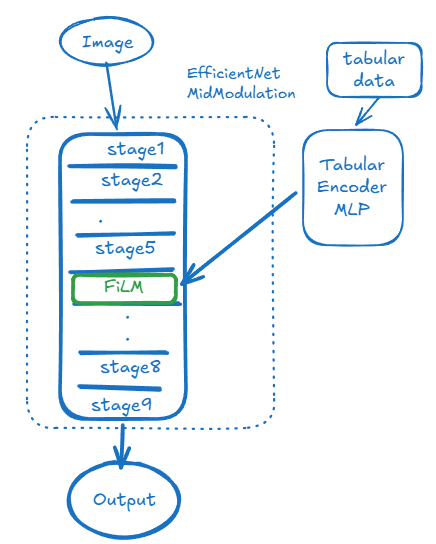



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../.."))

In [10]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_BN_fix_film_identity")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_BN_fix_film_identity"


TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)
    try:
        best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="film_fusion",   #film_fusion
        tab_cols=tab_cols,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
        identity_init=True, # film identity initialization instead of random
        ##film related parameter
        film_start_idx=3,                   # to update the backbone block at early stage on index 0 (1st block of EfficientNet)
        apply_to_all_after=False,            # True: apply FiLM toall blocks >= idx, False: only at idx, so here we only apply FiLM at 1st stage/block of EfficientNet
        use_bn_affine=True,                # False => BN used but only normalizes values and doest not apply affine transformation(gamma & beta), instead FiLM applies affine transformation
        freeze_backbone=True,              # False => finetune EfficientNet-B1,True -> Freezen backbone entirely
        BN_running_state_frozen=False
    )
    except Exception as e:
        import traceback
        print(f"\n[ERROR] Fold {fold} crashed")
        traceback.print_exc()
        raise    

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_BN_fix_film_identity: Fold 1 ===
[TRAIN BATCH 247] preds min=2.7214 max=11.2644 mean=6.2081var=4.2644
[TRAIN BATCH 247] loss=1478.7803
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=40.7407 | ValRMSE: 39.2247
[TRAIN BATCH 247] preds min=6.5958 max=20.4448 mean=14.2332var=12.0912
[TRAIN BATCH 247] loss=1021.6623
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=35.0962 | ValRMSE: 34.6633
[TRAIN BATCH 247] preds min=11.7529 max=37.1602 mean=21.3715var=37.5853
[TRAIN BATCH 247] loss=634.3145
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=29.9858 | ValRMSE: 30.9286
[TRAIN BATCH 247] preds min=9.6734 max=46.2347 mean=26.3212var=125.6820
[TRAIN BATCH 247] loss=1043.5647
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=26.7766 | ValRMSE: 29.0458
[TRAIN BATCH 247] preds min=12.2302 max=52.0485 mean=29.7329var=127.9453
[TRAIN BATCH 247] loss=584.9693
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=25.3925 | ValRMSE: 28.2263
[TRAIN BATCH 247] preds min=9.3651 max=51.5946 m

In [5]:

#OOF RMSE: 25.3272
import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 27.5083 (n=1983)
Fold 2 OOF RMSE: 26.3031 (n=1983)
Fold 3 OOF RMSE: 25.8707 (n=1982)
Fold 4 OOF RMSE: 26.4776 (n=1982)
Fold 5 OOF RMSE: 26.8684 (n=1982)


### Train and Validation RMSE Curve

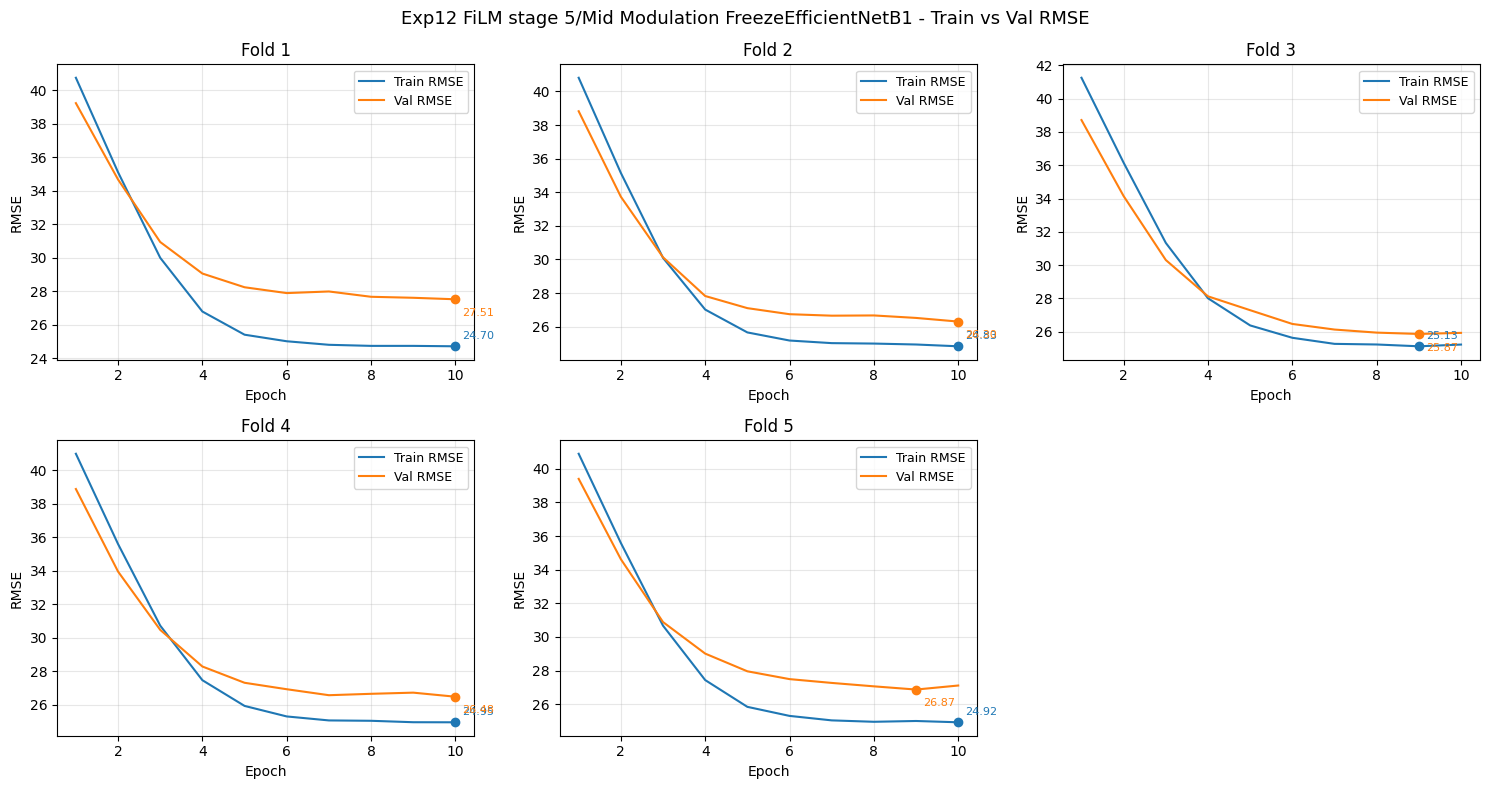

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM stage 5/Mid Modulation FreezeEfficientNetB1")

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)
    try:
        best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="film_fusion",   #film_fusion
        tab_cols=tab_cols,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
        identity_init=True, # film identity initialization instead of random
        ##film related parameter
        film_start_idx=3,                   # to update the backbone block at early stage on index 0 (1st block of EfficientNet)
        apply_to_all_after=False,            # True: apply FiLM toall blocks >= idx, False: only at idx, so here we only apply FiLM at 1st stage/block of EfficientNet
        use_bn_affine=True,                # False => BN used but only normalizes values and doest not apply affine transformation(gamma & beta), instead FiLM applies affine transformation
        freeze_backbone=True,              # False => finetune EfficientNet-B1,True -> Freezen backbone entirely
        BN_running_state_frozen=True
    )
    except Exception as e:
        import traceback
        print(f"\n[ERROR] Fold {fold} crashed")
        traceback.print_exc()
        raise    

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_BN_fix_film_identity: Fold 1 ===
[TRAIN BATCH 247] preds min=0.0897 max=0.5768 mean=0.2845var=0.0182
[TRAIN BATCH 247] loss=1838.4813
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=4877970642356.0342 | ValRMSE: 319371739136.0000
[TRAIN BATCH 247] preds min=-0.1679 max=0.5739 mean=0.2781var=0.0245
[TRAIN BATCH 247] loss=1867.2356
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=1805474886493.4697 | ValRMSE: 319050317824.0000
[TRAIN BATCH 247] preds min=0.0772 max=80408633344.0000 mean=3216345344.0000var=258621935390587617280.0000
[TRAIN BATCH 247] loss=258621935390587617280.0000
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=589216582585.3721 | ValRMSE: 318833590272.0000
[TRAIN BATCH 247] preds min=0.0405 max=0.4758 mean=0.2645var=0.0089
[TRAIN BATCH 247] loss=2375.8577
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=1782910341599.1299 | ValRMSE: 318716903424.0000
[TRAIN BATCH 247] preds min=0.0890 max=0.4714 mean=0.2397var=0.0130
[TRAIN BATCH 247] loss

In [12]:
import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 318519534648.8608 (n=1983)
Fold 2 OOF RMSE: 18481876862792.3906 (n=1983)
Fold 3 OOF RMSE: 38138884658.0059 (n=1982)
Fold 4 OOF RMSE: 498838112381.5547 (n=1982)
Fold 5 OOF RMSE: 921046315790.1268 (n=1982)


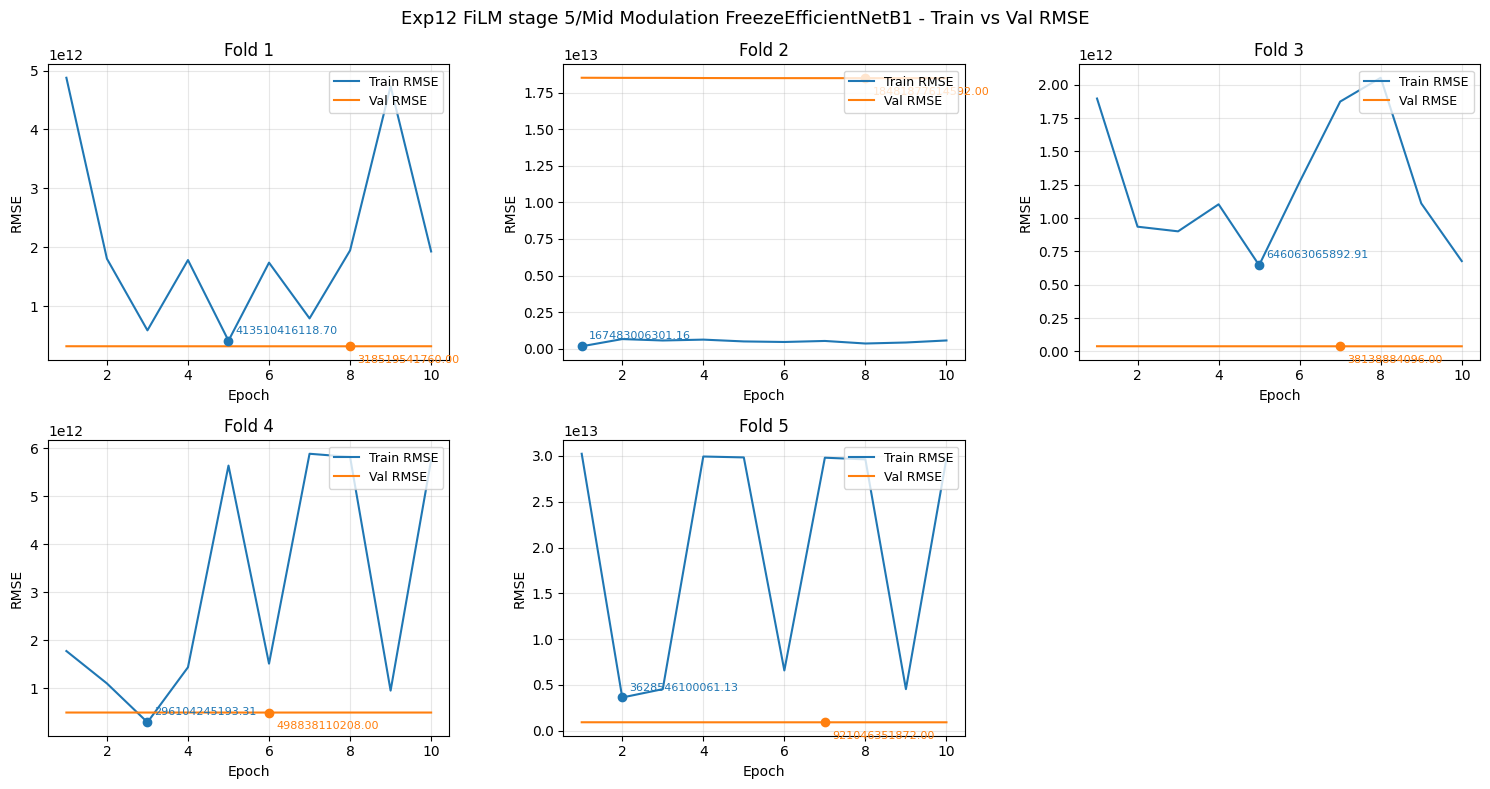

In [13]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM stage 5/Mid Modulation FreezeEfficientNetB1")